In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [5]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [42]:
OUTPUT_DIR = Path("../worldbank_tableau_project/outputs/country_indicators")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('../worldbank_tableau_project/outputs/country_indicators')

In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
traj_df = pd.read_csv("data/2_df_traj_clusters.csv")
traj_cat_df = (
    traj_df[["country_name", "traj_cluster", "Cluster_Name"]]
    .drop_duplicates()
    .rename(columns={"Cluster_Name": "Trajectory_Cluster_Name"})
)

traj_cat_df.head()

,country_name,traj_cluster,Trajectory_Cluster_Name
0,Algeria,1,Education-Led Social Improvers
1,Bahrain,5,Steady Reformers
2,"Egypt, Arab Rep.",1,Education-Led Social Improvers
3,"Iran, Islamic Rep.",1,Education-Led Social Improvers
4,Iraq,1,Education-Led Social Improvers


In [26]:
ind_meta = pd.read_csv("data/Main_Indicator_clusters.csv")

# Keep only what we need
indicator_meta = (
    ind_meta[["indicator_name", "indicator_cluster", "cluster_name"]]
    .drop_duplicates()
    .rename(columns={"cluster_name": "Indicator_Cluster_Name"})
)

indicator_meta.head()


,indicator_name,indicator_cluster,Indicator_Cluster_Name
0,A woman can apply for a passport in the same w...,3,Stable Legal Rights
1,"A woman can be ""head of household"" in the same...",0,Gradual Structural Demographic
2,A woman can choose where to live in the same w...,6,Fully Stabilized Rights
3,A woman can get a job in the same way as a man...,6,Fully Stabilized Rights
4,A woman can obtain a judgment of divorce in th...,6,Fully Stabilized Rights


In [27]:
panel = pd.read_csv("data/2IND_df.csv")
panel.columns


Index(['country_name', 'year', 'value', 'indicator_id', 'indicator_name',
       'unit_type', 'source', 'source_reliable', 'region', 'category',
       'val_num', 'yoy_change', 'yoy_pct_change', 'yoy_pct_exists',
       'rolling_mean_3y', 'rolling_std_3y', 'rolling_mean_5y',
       'rolling_std_5y', 'cagr', 'spike', 'dip', 'outlier', 'trend_slope',
       'coef_variation', 'momentum', 'regional_deviation',
       'regional_deviation_std', 'event_global', 'event_country',
       'indicator_cluster'],
      dtype='object')

In [30]:
panel = panel.merge(
    traj_cat_df[["country_name", "traj_cluster", "Trajectory_Cluster_Name"]],
    on="country_name",
    how="left"
)

panel[["country_name", "year", "indicator_name", "indicator_cluster", "traj_cluster"]].head(20)


,country_name,year,indicator_name,indicator_cluster,traj_cluster
0,Algeria,2000,A woman can apply for a passport in the same w...,3,1
1,Algeria,2001,A woman can apply for a passport in the same w...,3,1
2,Algeria,2002,A woman can apply for a passport in the same w...,3,1
3,Algeria,2003,A woman can apply for a passport in the same w...,3,1
4,Algeria,2004,A woman can apply for a passport in the same w...,3,1
5,Algeria,2005,A woman can apply for a passport in the same w...,3,1
6,Algeria,2006,A woman can apply for a passport in the same w...,3,1
7,Algeria,2007,A woman can apply for a passport in the same w...,3,1
8,Algeria,2008,A woman can apply for a passport in the same w...,3,1
9,Algeria,2009,A woman can apply for a passport in the same w...,3,1


In [32]:
panel["traj_cluster"].isna().sum()   # should be 0



0

In [34]:
panel["indicator_cluster"].isna().sum()  # should be 0

0

## For each trajectory cluster, which indicator behavior clusters contribute most to spikes, dips, outliers, and volatility?

In [35]:
feature_cols = [
    "rolling_std_5y",       # volatility proxy
    "trend_slope",
    "coef_variation",
    "momentum",
    "regional_deviation",
    "regional_deviation_std",
]


In [36]:
agg = (
    panel
    .groupby(["traj_cluster", "Trajectory_Cluster_Name", "indicator_cluster"], dropna=False)
    .agg(
        obs_count      = ("value", "count"),
        spike_count    = ("spike", "sum"),
        dip_count      = ("dip", "sum"),
        outlier_count  = ("outlier", "sum"),
        avg_volatility = ("rolling_std_5y", "mean"),
        avg_trend      = ("trend_slope", "mean"),
        avg_momentum   = ("momentum", "mean"),
        avg_coef_var   = ("coef_variation", "mean"),
        avg_reg_dev    = ("regional_deviation", "mean"),
        avg_reg_dev_sd = ("regional_deviation_std", "mean"),
    )
    .reset_index()
)

# Rates
agg["spike_rate"]   = agg["spike_count"]   / agg["obs_count"]
agg["dip_rate"]     = agg["dip_count"]     / agg["obs_count"]
agg["outlier_rate"] = agg["outlier_count"] / agg["obs_count"]

agg.head()


,traj_cluster,Trajectory_Cluster_Name,indicator_cluster,obs_count,spike_count,dip_count,outlier_count,avg_volatility,avg_trend,avg_momentum,avg_coef_var,avg_reg_dev,avg_reg_dev_sd,spike_rate,dip_rate,outlier_rate
0,0,Steady Moderate Improvers,0,576,5,3,5,0.733056,0.110953,0.000282,6.198770,4.966375e-01,0.023741,0.008681,0.005208,0.008681
1,0,Steady Moderate Improvers,1,864,44,4,66,1.060091,0.308566,-inf,47.052592,-3.501694e+03,-0.024891,0.050926,0.004630,0.076389
2,0,Steady Moderate Improvers,2,96,0,0,0,232211.635108,168560.415870,0.000332,32.230368,-3.483170e+06,-0.381766,0.000000,0.000000,0.000000
3,0,Steady Moderate Improvers,3,576,17,0,22,NaN,0.009946,-inf,201.290565,-4.340278e-04,-0.001044,0.029514,0.000000,0.038194
4,0,Steady Moderate Improvers,4,288,7,0,8,1.757798,-0.265198,-0.002605,37.660840,5.408023e-01,-0.123768,0.024306,0.000000,0.027778


In [37]:
cluster_names = {
    0: "Gradual Structural Demographic",
    1: "Highly Volatile, Reform-Sensitive",
    2: "Outlier: Population Dynamics",
    3: "Stable Legal Rights",
    4: "Declining Health & Fertility",
    5: "Growing Participation & Economic",
    6: "Fully Stabilized Rights",
    7: "Labor Market Stress & Unemployment"
}

agg["Indicator_Cluster_Name"] = agg["indicator_cluster"].map(cluster_names)
agg.head()


,traj_cluster,Trajectory_Cluster_Name,indicator_cluster,obs_count,spike_count,dip_count,outlier_count,avg_volatility,avg_trend,avg_momentum,avg_coef_var,avg_reg_dev,avg_reg_dev_sd,spike_rate,dip_rate,outlier_rate,Indicator_Cluster_Name
0,0,Steady Moderate Improvers,0,576,5,3,5,0.733056,0.110953,0.000282,6.198770,4.966375e-01,0.023741,0.008681,0.005208,0.008681,Gradual Structural Demographic
1,0,Steady Moderate Improvers,1,864,44,4,66,1.060091,0.308566,-inf,47.052592,-3.501694e+03,-0.024891,0.050926,0.004630,0.076389,"Highly Volatile, Reform-Sensitive"
2,0,Steady Moderate Improvers,2,96,0,0,0,232211.635108,168560.415870,0.000332,32.230368,-3.483170e+06,-0.381766,0.000000,0.000000,0.000000,Outlier: Population Dynamics
3,0,Steady Moderate Improvers,3,576,17,0,22,NaN,0.009946,-inf,201.290565,-4.340278e-04,-0.001044,0.029514,0.000000,0.038194,Stable Legal Rights
4,0,Steady Moderate Improvers,4,288,7,0,8,1.757798,-0.265198,-0.002605,37.660840,5.408023e-01,-0.123768,0.024306,0.000000,0.027778,Declining Health & Fertility


### Matrix: Trajectory Cluster × Indicator Cluster

In [38]:
spike_matrix = agg.pivot_table(
    index=["traj_cluster", "Trajectory_Cluster_Name"],
    columns="Indicator_Cluster_Name",
    values="spike_rate"
)

spike_matrix


,Indicator_Cluster_Name,Declining Health & Fertility,Fully Stabilized Rights,Gradual Structural Demographic,Growing Participation & Economic,"Highly Volatile, Reform-Sensitive",Labor Market Stress & Unemployment,Outlier: Population Dynamics,Stable Legal Rights
traj_cluster,Trajectory_Cluster_Name,,,,,,,,
0,Steady Moderate Improvers,0.024306,0.004735,0.008681,0.023438,0.050926,0.020833,0.0,0.029514
1,Education-Led Social Improvers,0.035494,0.001263,0.007716,0.011574,0.022634,0.016204,0.0,0.002315
2,Morocco,0.013889,0.000000,0.000000,0.000000,0.013889,0.020833,0.0,0.000000
3,UAE,0.041667,0.049242,0.000000,0.083333,0.092593,0.020833,0.0,0.027778
4,Palestine,0.041667,0.007576,0.000000,0.020833,0.013889,0.020833,0.0,0.000000
5,Steady Reformers,0.034722,0.017045,0.013889,0.005208,0.062500,0.031250,0.0,0.076389


In [39]:
dip_matrix = agg.pivot_table(
    index=["traj_cluster", "Trajectory_Cluster_Name"],
    columns="Indicator_Cluster_Name",
    values="dip_rate"
)
dip_matrix



,Indicator_Cluster_Name,Declining Health & Fertility,Fully Stabilized Rights,Gradual Structural Demographic,Growing Participation & Economic,"Highly Volatile, Reform-Sensitive",Labor Market Stress & Unemployment,Outlier: Population Dynamics,Stable Legal Rights
traj_cluster,Trajectory_Cluster_Name,,,,,,,,
0,Steady Moderate Improvers,0.000000,0.000000,0.005208,0.010417,0.004630,0.005208,0.0,0.000000
1,Education-Led Social Improvers,0.000000,0.000842,0.016975,0.011574,0.004115,0.004630,0.0,0.000000
2,Morocco,0.000000,0.000000,0.041667,0.125000,0.074074,0.000000,0.0,0.055556
3,UAE,0.000000,0.000000,0.034722,0.000000,0.009259,0.020833,0.0,0.000000
4,Palestine,0.000000,0.000000,0.027778,0.000000,0.000000,0.020833,0.0,0.000000
5,Steady Reformers,0.013889,0.000000,0.003472,0.000000,0.006944,0.010417,0.0,0.000000


In [40]:
outlier_matrix = agg.pivot_table(
    index=["traj_cluster", "Trajectory_Cluster_Name"],
    columns="Indicator_Cluster_Name",
    values="outlier_rate"
)

outlier_matrix

,Indicator_Cluster_Name,Declining Health & Fertility,Fully Stabilized Rights,Gradual Structural Demographic,Growing Participation & Economic,"Highly Volatile, Reform-Sensitive",Labor Market Stress & Unemployment,Outlier: Population Dynamics,Stable Legal Rights
traj_cluster,Trajectory_Cluster_Name,,,,,,,,
0,Steady Moderate Improvers,0.027778,0.012311,0.008681,0.033854,0.076389,0.000000,0.0,0.038194
1,Education-Led Social Improvers,0.055556,0.002946,0.027006,0.034722,0.056070,0.016204,0.0,0.018519
2,Morocco,0.000000,0.000000,0.027778,0.093750,0.148148,0.020833,0.0,0.055556
3,UAE,0.027778,0.045455,0.055556,0.104167,0.180556,0.020833,0.0,0.208333
4,Palestine,0.055556,0.007576,0.013889,0.020833,0.013889,0.041667,0.0,0.000000
5,Steady Reformers,0.034722,0.028409,0.072917,0.114583,0.118056,0.041667,0.0,0.170139


In [43]:
spike_matrix.to_csv(f"{OUTPUT_DIR}/traj_indicator_spike_matrix.csv")
dip_matrix.to_csv(f"{OUTPUT_DIR}/traj_indicator_dip_matrix.csv")
outlier_matrix.to_csv(f"{OUTPUT_DIR}/traj_indicator_outlier_matrix.csv")


## Visual Overview – Heatmap

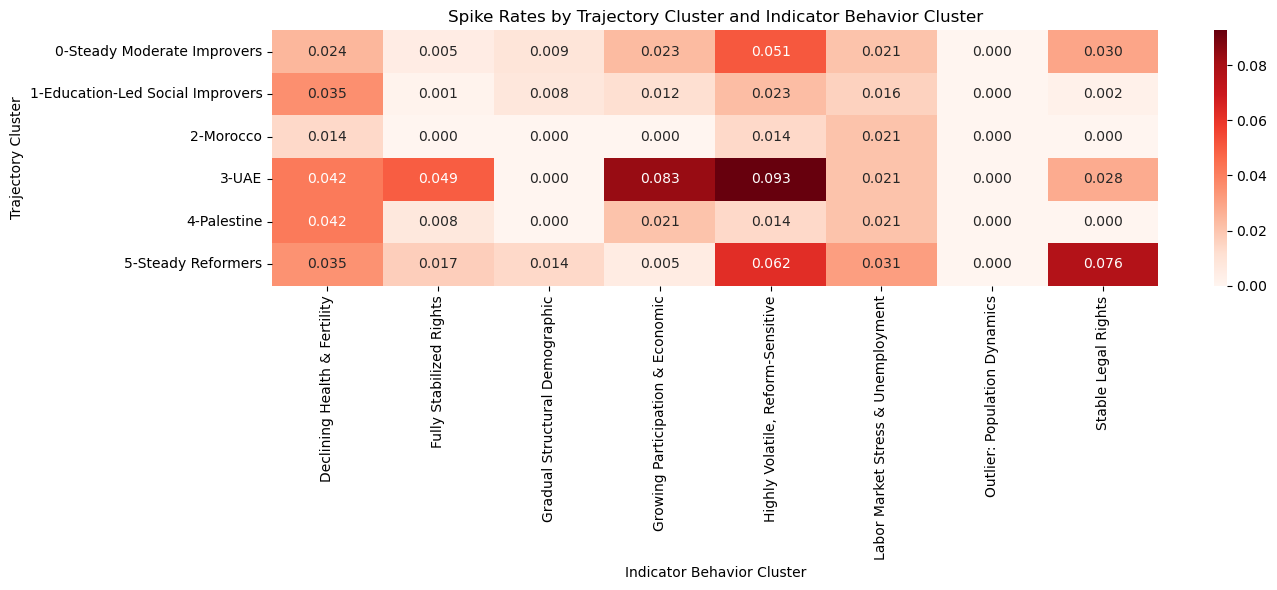

In [44]:
plt.figure(figsize=(14, 6))
sns.heatmap(
    spike_matrix,
    annot=True,
    fmt=".3f",
    cmap="Reds"
)
plt.title("Spike Rates by Trajectory Cluster and Indicator Behavior Cluster")
plt.xlabel("Indicator Behavior Cluster")
plt.ylabel("Trajectory Cluster")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/traj_indicator_spike_heatmap.png", dpi=300)
plt.show()


## Narrative Helper: Which Indicator Behaviors Drive Each Trajectory Cluster?

In [45]:
def summarize_traj_cluster(agg_df, traj_id, top_k=2):
    sub = agg_df[agg_df["traj_cluster"] == traj_id].copy()
    
    if sub.empty:
        return f"No data for trajectory cluster {traj_id}"
    
    # sort by spike_rate + outlier_rate combined
    sub["shock_intensity"] = sub["spike_rate"] + sub["outlier_rate"]
    
    top = (
        sub.sort_values("shock_intensity", ascending=False)
           .head(top_k)
           [["Indicator_Cluster_Name", "spike_rate", "outlier_rate", "avg_volatility"]]
    )
    
    traj_name = sub["Trajectory_Cluster_Name"].iloc[0]
    
    lines = [f"### Trajectory Cluster {traj_id} — {traj_name}"]
    lines.append("Dominant indicator behavior clusters (by spikes + outliers):")
    
    for _, row in top.iterrows():
        lines.append(
            f"- **{row['Indicator_Cluster_Name']}** — "
            f"spike_rate={row['spike_rate']:.3f}, "
            f"outlier_rate={row['outlier_rate']:.3f}, "
            f"avg_volatility={row['avg_volatility']:.3f}"
        )
    
    return "\n".join(lines)


In [46]:
traj_ids = agg["traj_cluster"].unique()

for tid in sorted(traj_ids):
    print(summarize_traj_cluster(agg, tid))
    print("\n" + "="*90 + "\n")


### Trajectory Cluster 0 — Steady Moderate Improvers
Dominant indicator behavior clusters (by spikes + outliers):
- **Highly Volatile, Reform-Sensitive** — spike_rate=0.051, outlier_rate=0.076, avg_volatility=1.060
- **Stable Legal Rights** — spike_rate=0.030, outlier_rate=0.038, avg_volatility=nan


### Trajectory Cluster 1 — Education-Led Social Improvers
Dominant indicator behavior clusters (by spikes + outliers):
- **Declining Health & Fertility** — spike_rate=0.035, outlier_rate=0.056, avg_volatility=2.199
- **Highly Volatile, Reform-Sensitive** — spike_rate=0.023, outlier_rate=0.056, avg_volatility=1668.289


### Trajectory Cluster 2 — Morocco
Dominant indicator behavior clusters (by spikes + outliers):
- **Highly Volatile, Reform-Sensitive** — spike_rate=0.014, outlier_rate=0.148, avg_volatility=2.247
- **Growing Participation & Economic** — spike_rate=0.000, outlier_rate=0.094, avg_volatility=54.768


### Trajectory Cluster 3 — UAE
Dominant indicator behavior clusters (by spike

## Exports

In [47]:
spike_matrix.to_csv("traj_indicator_spike_matrix.csv")
outlier_matrix.to_csv("traj_indicator_outlier_matrix.csv")
dip_matrix.to_csv("traj_indicator_dip_matrix.csv")
